In [3]:
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import ultraplot as uplt
import xarray as xr
import cartopy.crs as ccrs
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape
from rasterio.features import shapes
from affine import Affine
from rasterio.features import rasterize
import xarray as xr
import cartopy.feature as cfeature
from numpy import ma 
from scipy.interpolate import interp1d
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerLine2D

import rioxarray


uplt.rc.style='seaborn-v0_8-paper'
uplt.rc.update({'tick.len': 2.0, 'tick.dir': 'in', 'font.largesize': 12, 'font.smallsize': 10})

In [4]:
222

222

In [5]:
# Function to retrieve temporal R² results for SoMo model across multiple seeds
def get_t2_temperal_somo(seeds, model_type):
    # Determine base directory path based on model type
    if model_type == "c1d":
        fold = "/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c1d-2/"
    elif model_type == "c3d":
        fold = "/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d/"
    elif model_type == "kc3d":
        fold = "/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/"
    
    reslist = []
    # Process each seed's results
    for k in seeds:
        folder_path = fold + str(k)
        f = folder_path + "/"
        # Read temporal R² results from CSV file
        r2_df = pd.read_csv(f + "r2_temperal.csv")
        # Extract R² values column
        reslist.append(r2_df["r2"])
        reslist = reslist
    
    # Combine results from all seeds into single DataFrame
    res_df = pd.concat(reslist, axis=1)
    # Add month information from original data
    res_df["month"] = r2_df["month"]
    # Calculate mean R² across all seed runs
    res_df["mean"] = np.mean(res_df.iloc[:, :len(seeds)], axis=1)
    return res_df

# Function to compute smoothed temporal R² values using moving window
def get_r2_temperal(r2_values):
    r2list1 = []
    # Process 18 time periods (likely 18 years with monthly data)
    for i in range(18):
        if i == 0:
            # For first period: average first 6 months only (no previous data)
            r2list1.append(np.nanmean(r2_values[i*12:i*12+6]))
        else:
            # For subsequent periods: average 12-month window centered on current year
            r2list1.append(np.mean(r2_values[i*12-6:i*12+6]))
    return np.array(r2list1)

In [6]:
# Define seed lists for different SoMo model configurations
# Note: ESA-ERA model seeds are commented out for reference

# ESA-ERA model seeds (commented out):
# seeds_esa_era_c1d = [52, 57, 58, 59]
# seeds_esa_era_kc3d = [541, 540, 548]  # 540
# seeds_esa_era_c3d = [513, 512, 511]   # 511

# SoMo model seeds (active):
seeds_somo_c1d = [49, 60, 61, 62]      # Seeds for 1D convolutional model
seeds_somo_c3d = [560, 564, 565, 566]  # Seeds for 3D convolutional model  
seeds_somo_kc3d = [567, 568, 569, 570] # Seeds for kernel-based 3D convolutional model

In [7]:
# Retrieve temporal R² results for SoMo 1D convolutional model
c1d = get_t2_temperal_somo(seeds=seeds_somo_c1d, model_type='c1d')

# Retrieve temporal R² results for SoMo 3D convolutional model  
c3d = get_t2_temperal_somo(seeds=seeds_somo_c3d, model_type='c3d')

# Retrieve temporal R² results for SoMo kernel-based 3D convolutional model
kc3d = get_t2_temperal_somo(seeds=seeds_somo_kc3d, model_type='kc3d')

In [8]:
# Load input data array from numpy file
x = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/xc_21.npy")
# Extract LAI (Leaf Area Index) data from specific spatial location (10,10) and first channel (0)
# Array dimensions: [time, depth, lat, lon, channels]
lai = x[:, :, 10, 10, 0]

In [9]:
# Calculate range (peak-to-peak) of LAI values for first 12 time steps across all locations
rang = np.ptp(lai[:, :12], axis=1)
# Calculate standard deviation of LAI values for first 12 time steps across all locations
std = np.std(lai[:, :12], axis=1)

# Reshape LAI data into 3D array: [737 locations, 18 years, 12 months]
lai_data = lai.reshape(737, 18, 12)

# Calculate annual mean LAI by averaging across months (axis=2)
time_ann = np.mean(lai_data, axis=2)
time_mean = np.mean(lai_data, axis=2)  # Same as time_ann, redundant but kept

# Calculate annual standard deviation of LAI across months
time_std = np.std(lai_data, axis=2)
# Calculate coefficient of variation (CV) for annual LAI (std/mean with epsilon to avoid division by zero)
time_cv = time_std / (time_mean + 1e-10)

# Calculate spatial standard deviation across all locations and years for each month
spatial_std = np.nanstd(lai_data, axis=(0))

# The following lines are commented out but show additional potential calculations:
# Calculate mean coefficient of variation across years for each location
# ann_time_cv = np.nanmean(time_cv, axis=0)
# Calculate mean annual standard deviation across years for each location  
# ann_time_std = np.nanmean(time_std, axis=0)
# Calculate mean spatial standard deviation across months for each year
# annual_spatial_std = np.nanmean(spatial_std, axis=1)

Text(0, 0.5, 'R²')

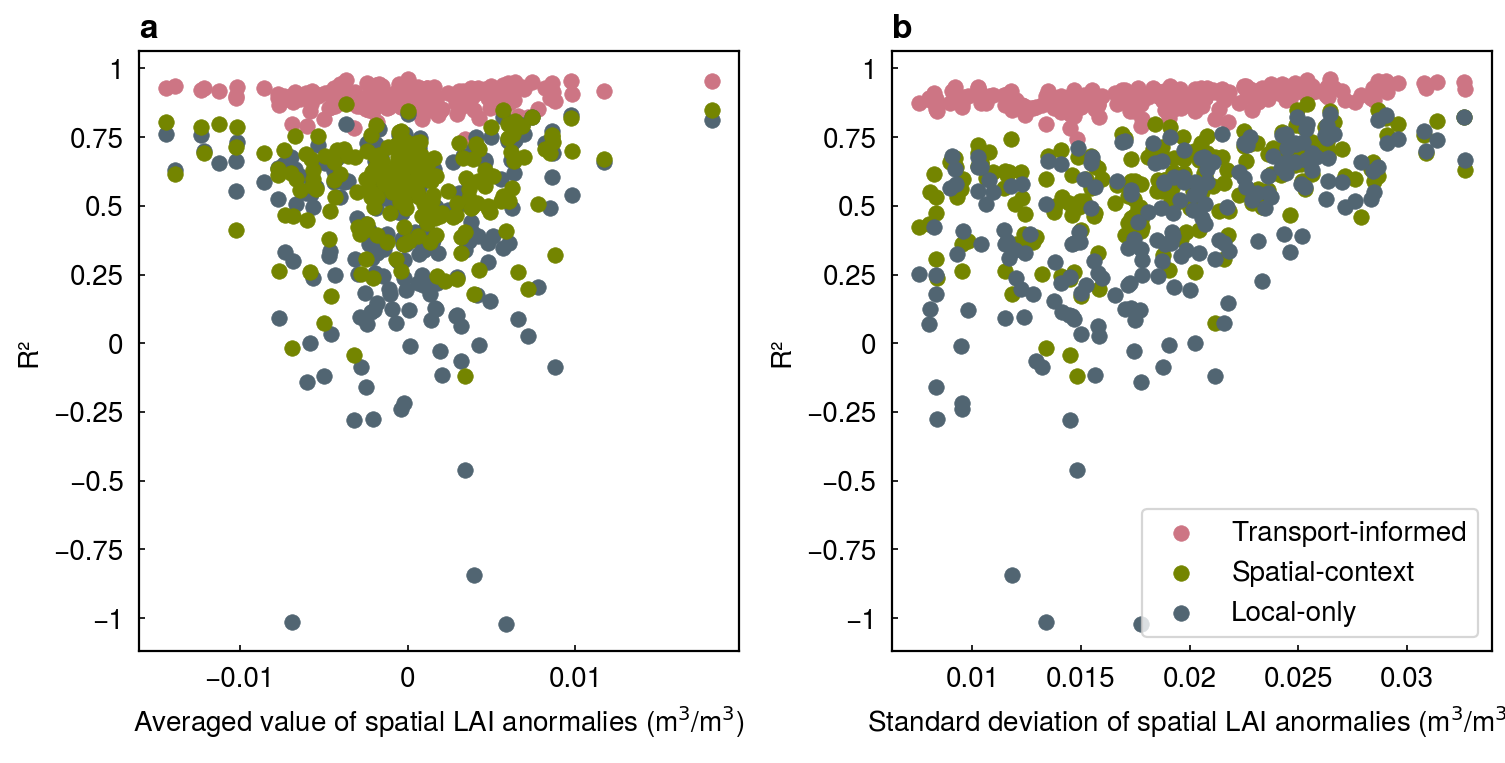

In [14]:
# Define subplot arrangement: 1 row with 2 columns
arrray = [[1, 2]]  # Subplot arrangement matrix

# Create figure with specified width and layout settings
fig = uplt.figure(refwidth=3, share=False, span=False, tight=True)
# Create subplots with specified arrangement and aspect ratios
axs = fig.subplots(arrray, abc=True, width_ratios=[1, 1], height_ratios=[1])

# First subplot: R² vs averaged LAI anomalies
ax = axs[0]
# Scatter plot for kernel-based 3D model (transport-informed)
ax.scatter(np.nanmean(lai[:, 6:], axis=0), kc3d['mean'], c='ugly pink')
# Scatter plot for 3D convolutional model (local-only)
ax.scatter(np.nanmean(lai[:, 6:], axis=0), c3d['mean'], c='slate')
# Scatter plot for 1D convolutional model (spatial-context)
ax.scatter(np.nanmean(lai[:, :], axis=0), c1d['mean'], c='swamp green')
# Set axis labels
ax.set_xlabel('Averaged value of spatial LAI anomalies (m$^3$/m$^3$)')
ax.set_ylabel('R²')

# Second subplot: R² vs standard deviation of LAI anomalies
ax = axs[1]
# Scatter plot for kernel-based 3D model with legend label
ax.scatter(spatial_std.reshape(-1, 1)[6:, 0], kc3d['mean'], c='ugly pink', label='Transport-informed')
# Scatter plot for 1D convolutional model with legend label (subset from index 6)
ax.scatter(spatial_std.reshape(-1, 1)[6:, 0], c1d['mean'][6:].values, c='swamp green', label='Spatial-context')
# Scatter plot for 3D convolutional model with legend label
ax.scatter(spatial_std.reshape(-1, 1)[6:, 0], c3d['mean'], c='slate', label='Local-only')
# Add legend with single column layout
ax.legend(ncol=1)
# Set axis labels
ax.set_xlabel('Standard deviation of spatial LAI anomalies (m$^3$/m$^3$)')
ax.set_ylabel('R²')